# Euclidena Distance Calculation

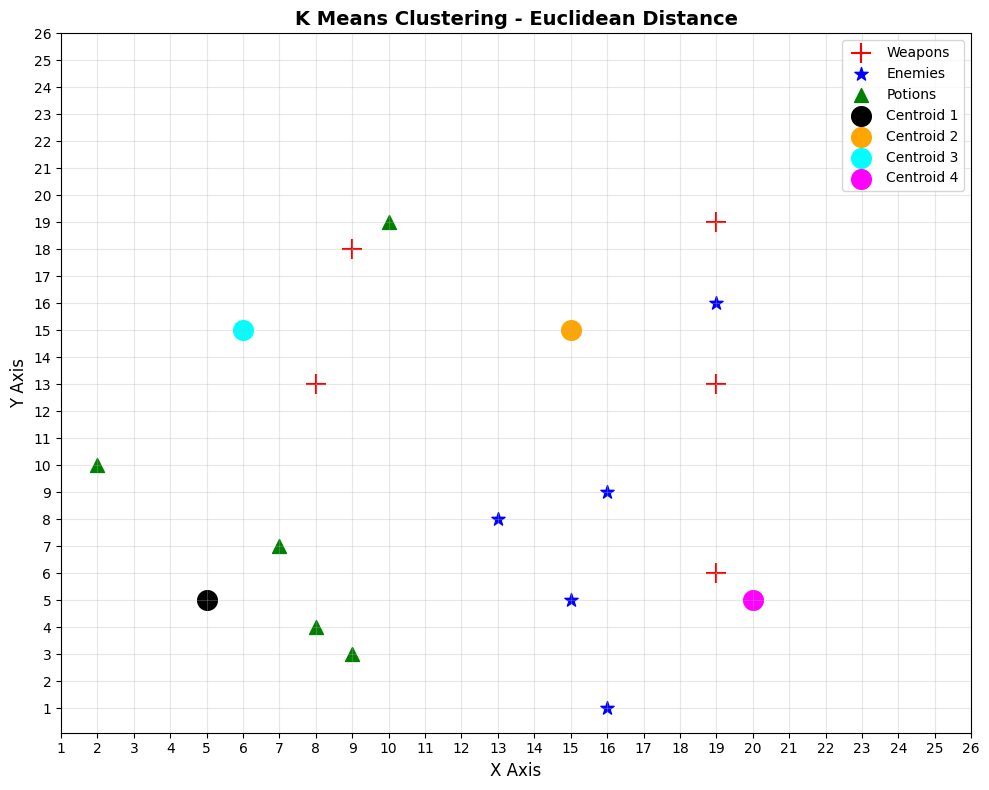

In [59]:
import numpy as np

import matplotlib.pyplot as plt

# Define 16 coordinates
weapons = np.array([[9, 18], [19, 19], [19, 13], [8, 13], [19, 6]])
enemies = np.array([[16, 1], [13, 8], [16, 9], [15, 5], [19, 16]])
potions = np.array([[8, 4], [2, 10], [9, 3], [7, 7], [10, 19]])


# Create a new figure for the coordinate graph
fig_coords, ax = plt.subplots(figsize=(10, 8))

# Plot the coordinates with different symbols
ax.scatter(weapons[:, 0], weapons[:, 1], marker='+', s=200, label='Weapons', color='red')
ax.scatter(enemies[:, 0], enemies[:, 1], marker='*', s=100, label='Enemies', color='blue')
ax.scatter(potions[:, 0], potions[:, 1], marker='^', s=100, label='Potions', color='green')

# Generate 4 random centroids
np.random.seed(42)
# centroids = np.random.uniform(1, 20, size=(4, 2))
centroids = np.array([[5, 5], [15, 15], [6, 15], [20, 5]])
centroid_colors = ['black', 'orange', 'cyan', 'magenta']
for i, color in enumerate(centroid_colors):
    ax.scatter(centroids[i, 0], centroids[i, 1], marker='o', s=200, label=f'Centroid {i+1}', color=color)

# Top-right corner


# Add grid and labels
ax.grid(True, alpha=0.3)
ax.set_xlabel('X Axis', fontsize=12)
ax.set_ylabel('Y Axis', fontsize=12)
ax.set_title('K Means Clustering - Euclidean Distance', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 27))
ax.set_yticks(range(1, 27))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

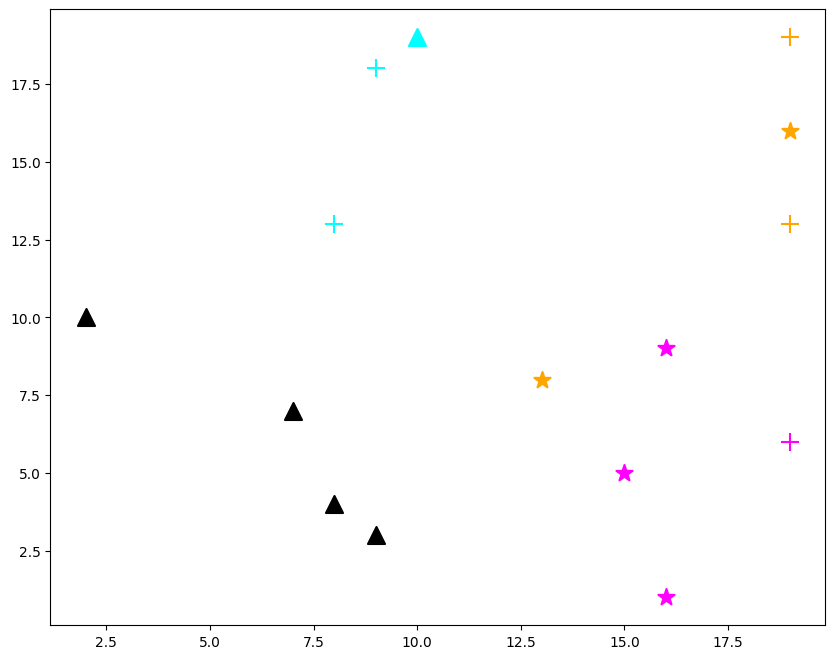

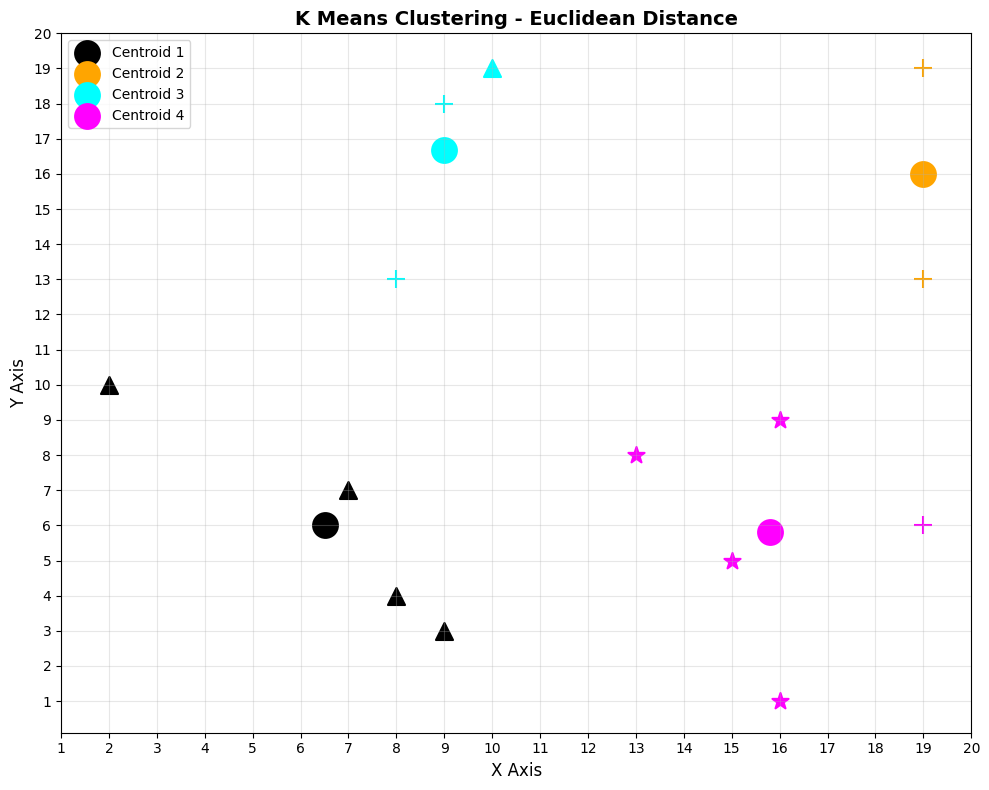

In [60]:
# Calculate Euclidean distance from each point to all centroids
all_points = np.vstack([weapons, enemies, potions])
point_labels = ['Weapon'] * len(weapons) + ['Enemy'] * len(enemies) + ['Potion'] * len(potions)
iterates = 2
for iteration in range(iterates):

    # Assign each point to nearest centroid
    distances = np.zeros((len(all_points), len(centroids)))
    for i, point in enumerate(all_points):
        for j, centroid in enumerate(centroids):
            distances[i, j] = np.linalg.norm(point - centroid)

    assignments = np.argmin(distances, axis=1)

    fig_coords, ax = plt.subplots(figsize=(10, 8))

    # Clear the plot and redraw with assigned colors
    ax.clear()
    for idx, point in enumerate(all_points):
        centroid_idx = assignments[idx]
        marker = '+' if point_labels[idx] == 'Weapon' else ('*' if point_labels[idx] == 'Enemy' else '^')
        ax.scatter(point[0], point[1], marker=marker, s=150, color=centroid_colors[centroid_idx], linewidth=1.5)
        # Calculate mean of each cluster
        new_centroids = np.array([all_points[assignments == i].mean(axis=0) for i in range(len(centroids))])
        centroids = new_centroids
        
# Redraw centroids
for i, color in enumerate(centroid_colors):
    ax.scatter(centroids[i, 0], centroids[i, 1], marker='o', s=300, label=f'Centroid {i+1}', color=color, linewidth=2)

ax.grid(True, alpha=0.3)
ax.set_xlabel('X Axis', fontsize=12)
ax.set_ylabel('Y Axis', fontsize=12)
ax.set_title('K Means Clustering - Euclidean Distance', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 21))
ax.set_yticks(range(1, 21))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Manhattan Distance Calculation

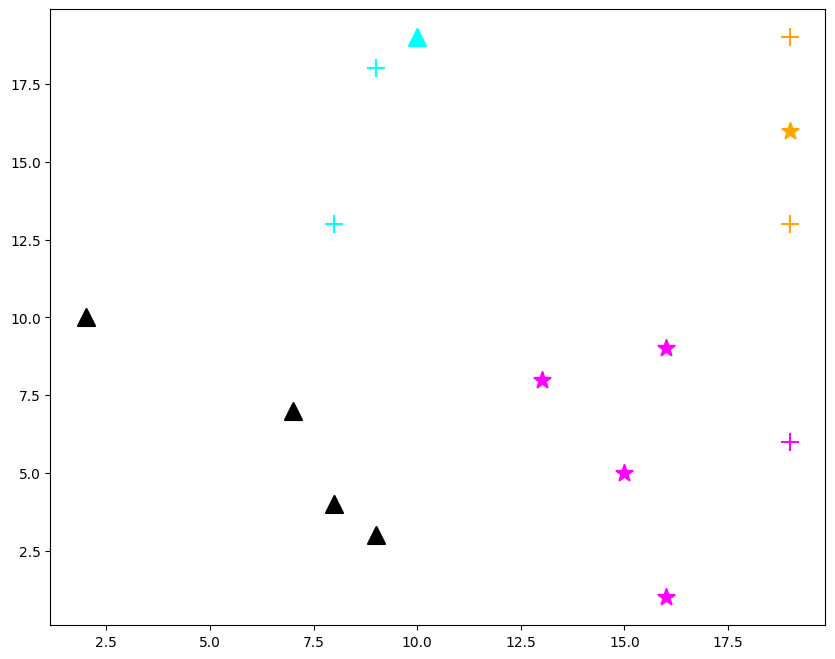

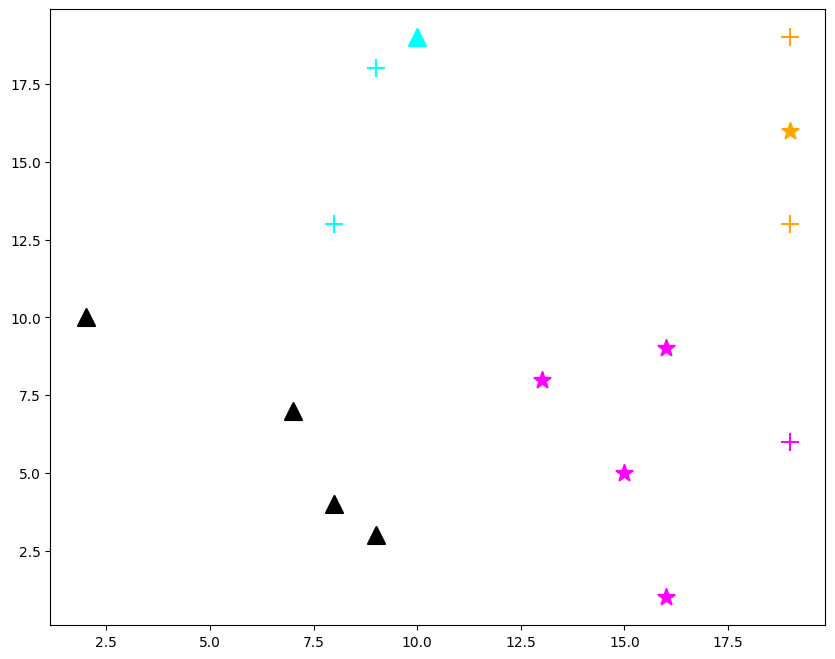

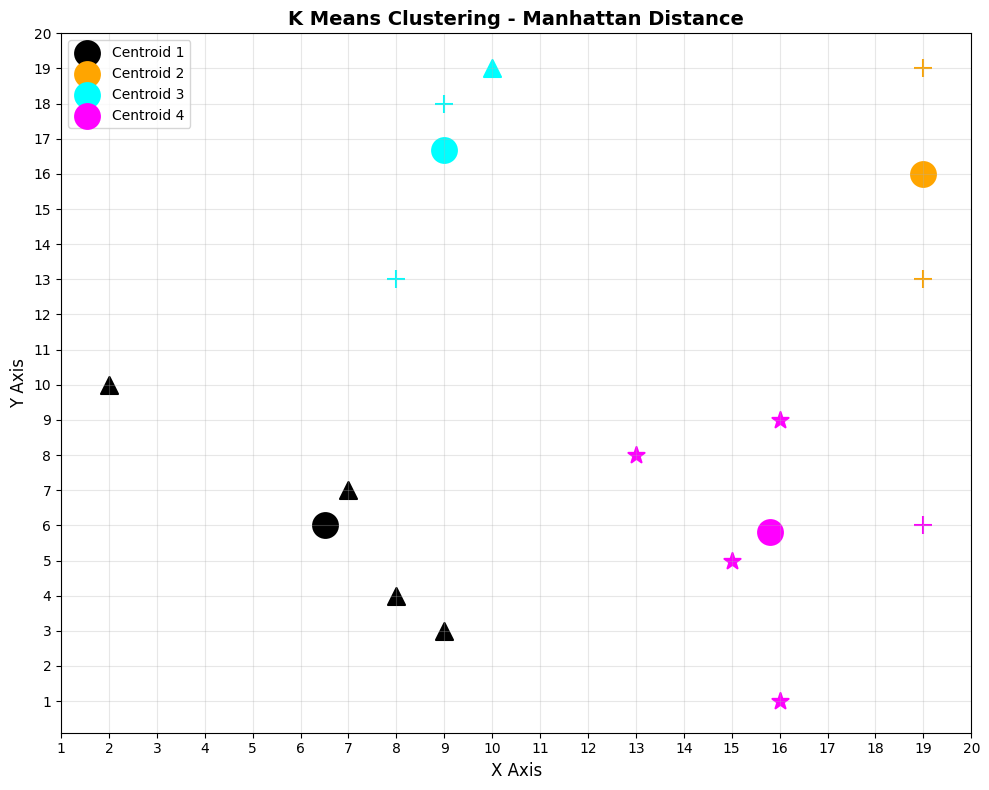

In [58]:
# Calculate Manhattan distance from each point to all centroids
iterates = 3
for iteration in range(iterates):

    # Assign each point to nearest centroid
    distances = np.zeros((len(all_points), len(centroids)))
    for i, point in enumerate(all_points):
        for j, centroid in enumerate(centroids):
            distances[i, j] = np.sum(np.abs(point - centroid))

    assignments = np.argmin(distances, axis=1)

    fig_coords, ax = plt.subplots(figsize=(10, 8))

    # Clear the plot and redraw with assigned colors
    ax.clear()
    for idx, point in enumerate(all_points):
        centroid_idx = assignments[idx]
        marker = '+' if point_labels[idx] == 'Weapon' else ('*' if point_labels[idx] == 'Enemy' else '^')
        ax.scatter(point[0], point[1], marker=marker, s=150, color=centroid_colors[centroid_idx], linewidth=1.5)
    
    # Calculate mean of each cluster
    new_centroids = np.array([all_points[assignments == i].mean(axis=0) for i in range(len(centroids))])
    centroids = new_centroids
        
# Redraw centroids
for i, color in enumerate(centroid_colors):
    ax.scatter(centroids[i, 0], centroids[i, 1], marker='o', s=300, label=f'Centroid {i+1}', color=color, linewidth=2)

ax.grid(True, alpha=0.3)
ax.set_xlabel('X Axis', fontsize=12)
ax.set_ylabel('Y Axis', fontsize=12)
ax.set_title('K Means Clustering - Manhattan Distance', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 21))
ax.set_yticks(range(1, 21))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()